In [1]:
import pymupdf
from pathlib import Path

# PDF_PATH = Path("../data/chapters/04_Otoczenie.pdf")
# PDF_PATH = Path("../data/chapters/05_Osiągnięcia.pdf")
# PDF_PATH = Path("../data/chapters/06_Ład_korporacyjny.pdf")
PDF_PATH = Path("../data/raport_2024_pl 1.pdf")
doc = pymupdf.open(PDF_PATH)

# filtr problematycznych stron
doc.select([7, 19, 44])  # modyfikuje dokument in-place
print(f"Liczba stron w rozdziale: {len(doc)}")

Liczba stron w rozdziale: 3


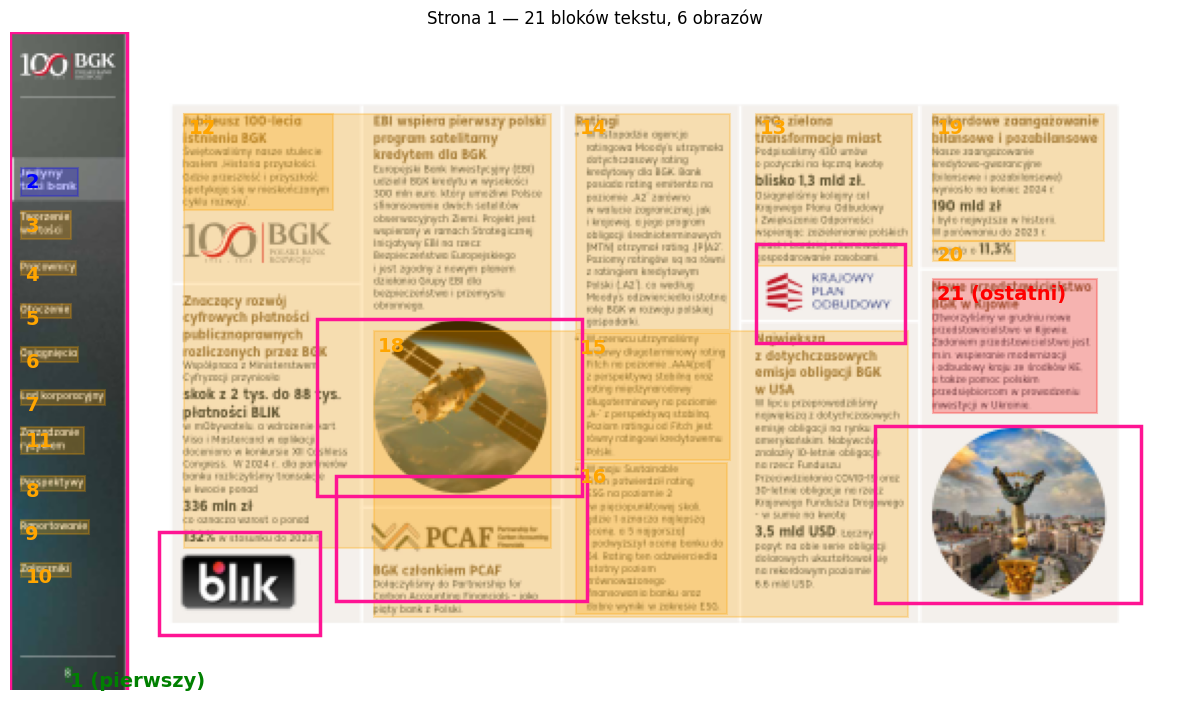

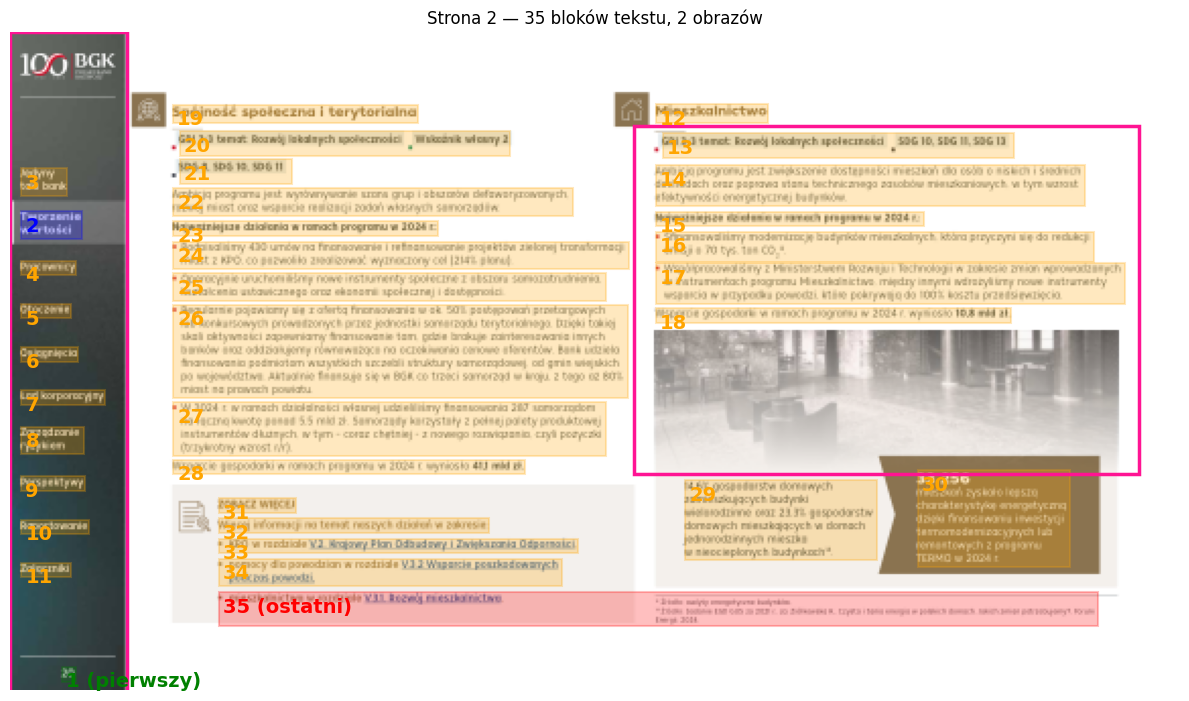

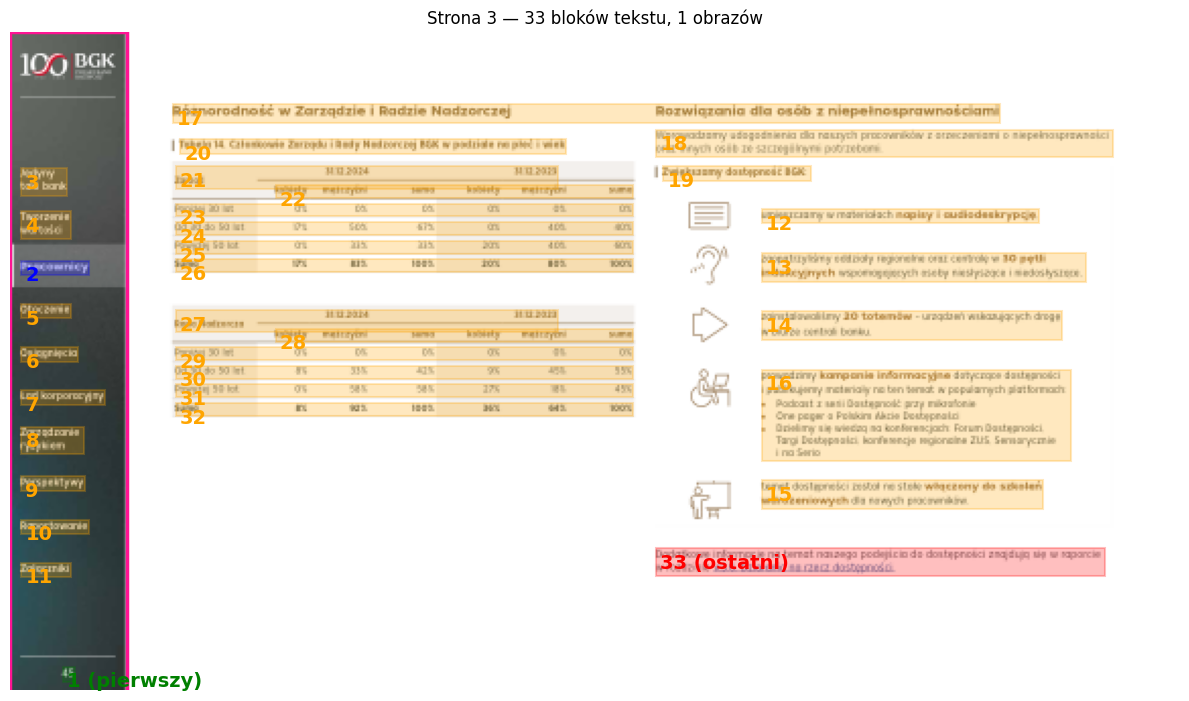

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches


def visualize_blocks(page_idx: int, scale: float = 0.3):
    page = doc[page_idx]

    mat = pymupdf.Matrix(scale, scale)
    pix = page.get_pixmap(matrix=mat)
    img = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, pix.n)
    if pix.n == 4:
        img = img[:, :, :3]

    blocks = [b for b in page.get_text("blocks") if b[6] == 0]  # typ 0 = tekst

    # Obrazy: get_images zwraca (xref, ...), get_image_rects daje bbox na stronie
    images = page.get_images(full=True)
    image_rects = []
    for img_info in images:
        xref = img_info[0]
        image_rects.extend(page.get_image_rects(xref))

    fig, ax = plt.subplots(figsize=(12, 8))
    ax.imshow(img)
    ax.set_title(f"Strona {page_idx + 1} — {len(blocks)} bloków tekstu, {len(image_rects)} obrazów")

    for idx, block in enumerate(blocks):
        x0, y0, x1, y1 = block[:4]

        if idx == 0:
            color, label = "green", "1 (pierwszy)"
        elif idx == 1:
            color, label = "blue", "2"
        elif idx == len(blocks) - 1:
            color, label = "red", f"{idx + 1} (ostatni)"
        else:
            color, label = "orange", str(idx + 1)

        rect = patches.Rectangle(
            (x0 * scale, y0 * scale),
            (x1 - x0) * scale,
            (y1 - y0) * scale,
            linewidth=1.5, edgecolor=color, facecolor=color, alpha=0.25,
        )
        ax.add_patch(rect)
        ax.text(x0 * scale + 2, y0 * scale + 10, label,
                color=color, fontsize=14, weight="bold")

    # Różowe ramki dla obrazów (get_images + get_image_rects)
    for rect in image_rects:
        pink_rect = patches.Rectangle(
            (rect.x0 * scale, rect.y0 * scale),
            (rect.x1 - rect.x0) * scale,
            (rect.y1 - rect.y0) * scale,
            linewidth=2.5, edgecolor="deeppink", facecolor="none",
        )
        ax.add_patch(pink_rect)

    ax.axis("off")
    plt.tight_layout()
    plt.show()


for idx in range(len(doc)):
    visualize_blocks(idx)

In [3]:
for page_idx in range(len(doc)):
    page = doc[page_idx]
    blocks = [b for b in page.get_text("blocks") if b[6] == 0]  # typ 0 = tekst
    print(f"\n{'='*60}")
    print(f"STRONA {page_idx + 1} — {len(blocks)} bloków tekstu")
    print(f"{'='*60}")
    for idx, block in enumerate(blocks):
        x0, y0, x1, y1, text, block_no, block_type = block
        print(f"\n--- Blok {idx + 1} (bbox: {x0:.0f},{y0:.0f} → {x1:.0f},{y1:.0f}) ---")
        print(repr(text))


STRONA 1 — 21 bloków tekstu

--- Blok 1 (bbox: 90,1040 → 100,1065) ---
'8\n'

--- Blok 2 (bbox: 17,221 → 110,267) ---
'Jedyny\ntaki bank\n'

--- Blok 3 (bbox: 17,292 → 98,338) ---
'Tworzenie\nwartości\n'

--- Blok 4 (bbox: 17,374 → 107,398) ---
'Pracownicy\n'

--- Blok 5 (bbox: 17,445 → 98,468) ---
'Otoczenie\n'

--- Blok 6 (bbox: 17,515 → 110,539) ---
'Osiągnięcia\n'

--- Blok 7 (bbox: 17,586 → 154,610) ---
'Ład korporacyjny\n'

--- Blok 8 (bbox: 17,728 → 121,752) ---
'Perspektywy\n'

--- Blok 9 (bbox: 17,799 → 128,822) ---
'Raportowanie\n'

--- Blok 10 (bbox: 17,869 → 98,893) ---
'Załączniki\n'

--- Blok 11 (bbox: 17,646 → 119,692) ---
'Zarządzanie \nryzykiem\n'

--- Blok 12 (bbox: 285,133 → 529,291) ---
'Jubileusz 100-lecia \nistnienia BGK\nŚwiętowaliśmy nasze stulecie \nhasłem „Historia przyszłości. \nGdzie przeszłość i przyszłość \nspotykają się w nieskończonym \ncyklu rozwoju”. \n'

--- Blok 13 (bbox: 1223,133 → 1478,382) ---
'KPO: zielona \ntransformacja miast\nPodpisaliśmy 430

In [4]:
def split_and_reassemble(text: str) -> list[str]:
    """
    Dzieli tekst bloku PyMuPDF na mniejsze fragmenty logiczne.

    Reguły:
      - linia kończy się spacją      → soft wrap (zawijanie tekstu w PDF),
                                        sklejamy z następną linią
      - linia jest pusta             → separator sekcji, zamyka bieżący fragment
      - linia nie kończy się spacją  → twarda granica zdania/paragrafu,
                                        zamyka bieżący fragment
    """
    lines = text.split('\n')
    chunks: list[str] = []
    current: list[str] = []

    for line in lines:
        if not line.strip():
            # pusta linia → zamknij bieżący fragment
            if current:
                chunk = ''.join(current).strip()
                if chunk:
                    chunks.append(chunk)
                current = []
        elif line.endswith(' '):
            # soft wrap → kontynuuj bieżące zdanie
            current.append(line)
        else:
            # twarda granica → zamknij bieżący fragment
            current.append(line)
            chunk = ''.join(current).strip()
            if chunk:
                chunks.append(chunk)
            current = []

    # ewentualne pozostałości na końcu
    if current:
        chunk = ''.join(current).strip()
        if chunk:
            chunks.append(chunk)

    return chunks

In [5]:
for page_idx in range(len(doc)):
    page = doc[page_idx]
    blocks = [b for b in page.get_text("blocks") if b[6] == 0]

    all_chunks = []
    split_report = []

    for idx, block in enumerate(blocks):
        x0, y0, x1, y1, text, block_no, block_type = block
        chunks = split_and_reassemble(text)
        all_chunks.extend(chunks)
        if len(chunks) > 1:
            split_report.append((idx + 1, len(text), chunks))

    print(f"\n{'='*60}")
    print(f"STRONA {page_idx + 1}: {len(blocks)} bloków → {len(all_chunks)} fragmentów po podziale")
    print(f"{'='*60}")

    if split_report:
        print("\nBloki rozbite na mniejsze części:")
        for blok_nr, orig_len, chunks in split_report:
            print(f"\n  Blok {blok_nr} ({orig_len} znaków) → {len(chunks)} fragmentów:")
            for i, ch in enumerate(chunks):
                print(f"    [{i+1}] {repr(ch[:100])}")
    else:
        print("  (żaden blok nie wymagał podziału)")

    sizes = [len(ch) for ch in all_chunks]
    print(f"\n  Rozmiary fragmentów: min={min(sizes)}, max={max(sizes)}, średnia={sum(sizes)/len(sizes):.0f} znaków")


STRONA 1: 21 bloków → 52 fragmentów po podziale

Bloki rozbite na mniejsze części:

  Blok 2 (17 znaków) → 2 fragmentów:
    [1] 'Jedyny'
    [2] 'taki bank'

  Blok 3 (19 znaków) → 2 fragmentów:
    [1] 'Tworzenie'
    [2] 'wartości'

  Blok 12 (175 znaków) → 2 fragmentów:
    [1] 'Jubileusz 100-lecia istnienia BGK'
    [2] 'Świętowaliśmy nasze stulecie hasłem „Historia przyszłości. Gdzie przeszłość i przyszłość spotykają s'

  Blok 13 (274 znaków) → 4 fragmentów:
    [1] 'KPO: zielona transformacja miast'
    [2] 'Podpisaliśmy 430 umów'
    [3] 'o pożyczki na łączną kwotę blisko 1,3 mld zł. Osiągnęliśmy kolejny cel Krajowego Planu Odbudowy'
    [4] 'i Zwiększania Odporności wspierając zazielenianie polskich miast i bardziej zrównoważone gospodarowa'

  Blok 14 (428 znaków) → 4 fragmentów:
    [1] 'Ratingi'
    [2] '▪W listopadzie agencja ratingowa Moody’s utrzymała dotychczasowy rating kredytowy dla BGK. Bank posi'
    [3] 'w walucie zagranicznej, jak'
    [4] 'i krajowej, a jego pr

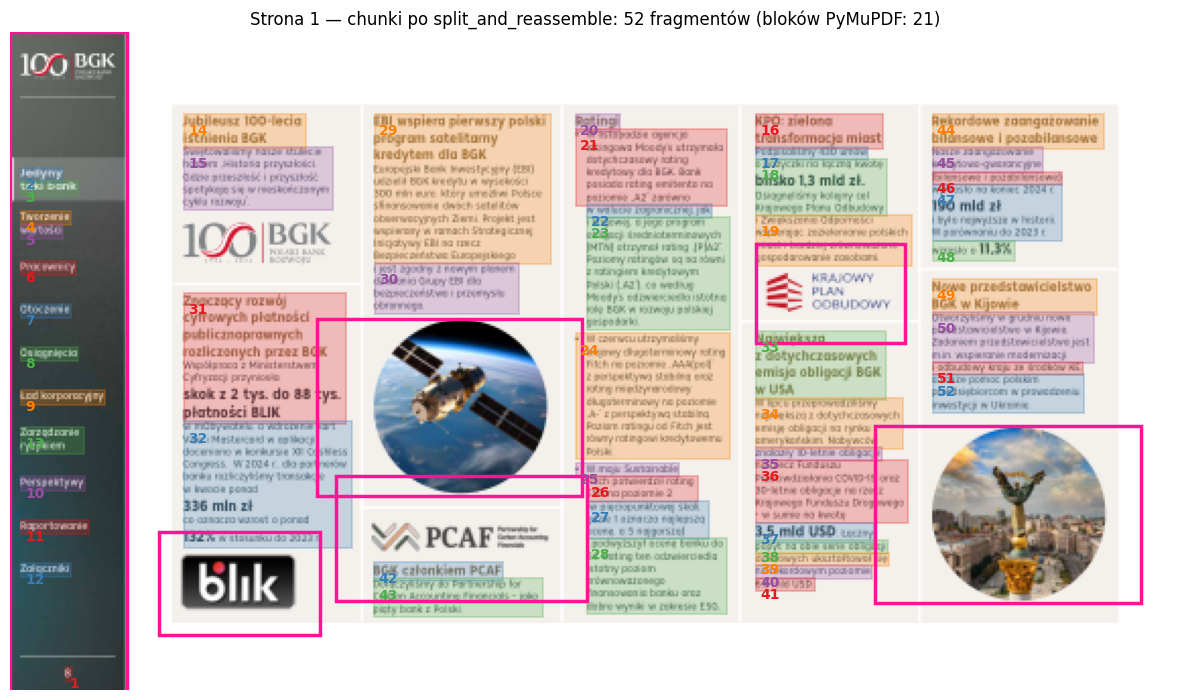

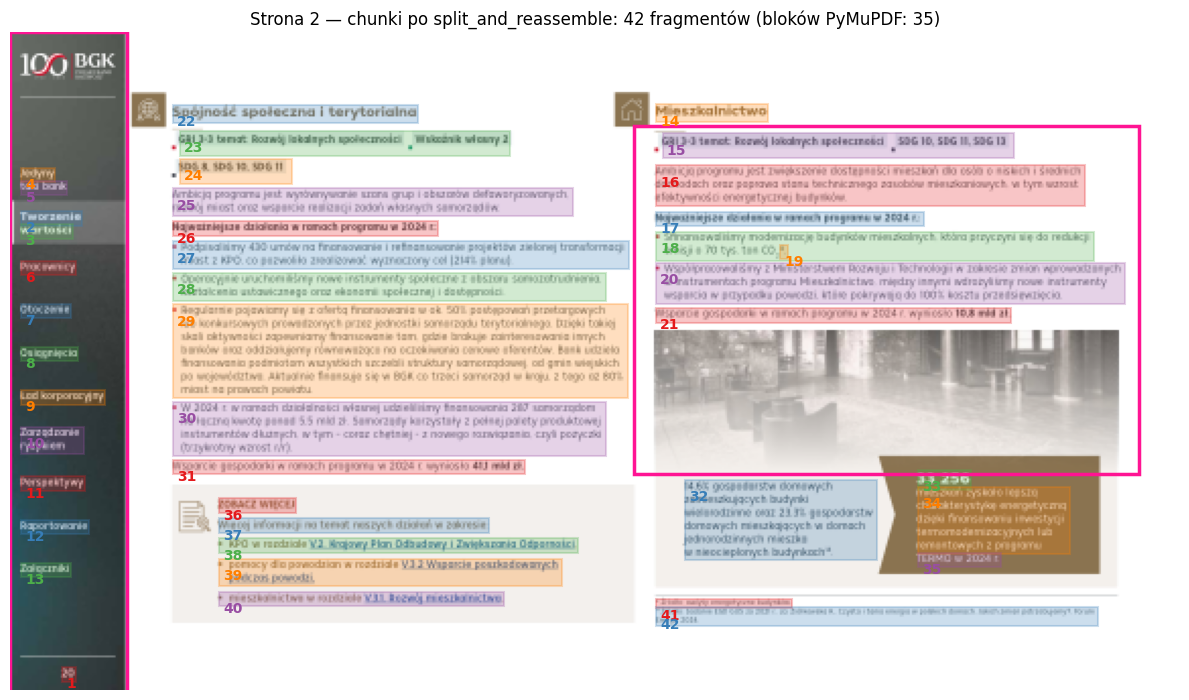

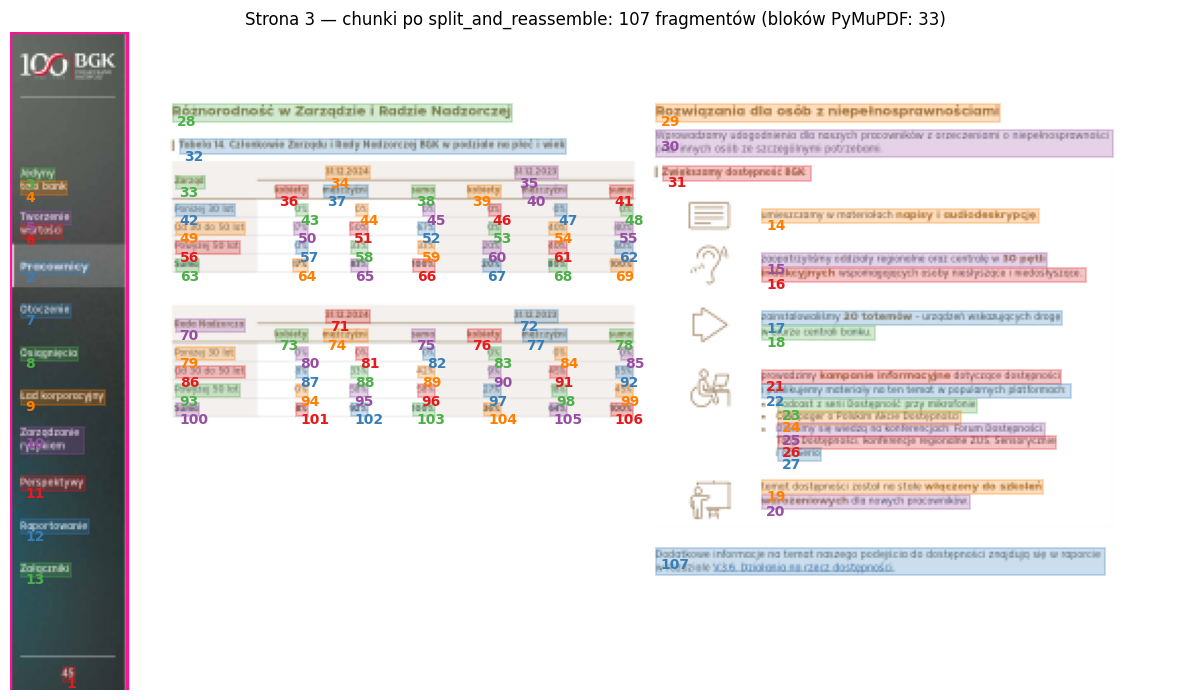

In [6]:
def get_chunk_bboxes(block: dict) -> list[tuple[tuple, str]]:
    """
    Dla bloku z get_text("dict") zwraca listę (bbox, text) per chunk logiczny.
    Stosuje tę samą regułę co split_and_reassemble:
      - linia kończy się spacją → soft wrap, sklejamy z następną
      - pusta linia             → separator sekcji, zamyka chunk
      - brak spacji na końcu    → twarda granica, zamyka chunk
    bbox chunku = union bboxów wszystkich linii należących do chunku.
    """
    result = []
    current_lines = []
    current_text = []

    def flush():
        if not current_lines:
            return
        x0 = min(ln["bbox"][0] for ln in current_lines)
        y0 = min(ln["bbox"][1] for ln in current_lines)
        x1 = max(ln["bbox"][2] for ln in current_lines)
        y1 = max(ln["bbox"][3] for ln in current_lines)
        text = "".join(current_text).strip()
        if text:
            result.append(((x0, y0, x1, y1), text))
        current_lines.clear()
        current_text.clear()

    for line in block.get("lines", []):
        line_text = "".join(span["text"] for span in line["spans"])

        if not line_text.strip():
            flush()
        elif line_text.endswith(" "):
            current_lines.append(line)
            current_text.append(line_text)
        else:
            current_lines.append(line)
            current_text.append(line_text)
            flush()

    flush()
    return result


def visualize_chunks(page_idx: int, scale: float = 0.3):
    page = doc[page_idx]

    mat = pymupdf.Matrix(scale, scale)
    pix = page.get_pixmap(matrix=mat)
    img = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, pix.n)
    if pix.n == 4:
        img = img[:, :, :3]

    d = page.get_text("dict")
    text_blocks = [b for b in d["blocks"] if b.get("type") == 0]

    all_chunk_bboxes = []
    for block in text_blocks:
        all_chunk_bboxes.extend(get_chunk_bboxes(block))

    images = page.get_images(full=True)
    image_rects = []
    for img_info in images:
        xref = img_info[0]
        image_rects.extend(page.get_image_rects(xref))

    fig, ax = plt.subplots(figsize=(12, 8))
    ax.imshow(img)
    ax.set_title(
        f"Strona {page_idx + 1} — chunki po split_and_reassemble: "
        f"{len(all_chunk_bboxes)} fragmentów (bloków PyMuPDF: {len(text_blocks)})"
    )

    colors = ["#e41a1c", "#377eb8", "#4daf4a", "#ff7f00", "#984ea3"]
    for i, (bbox, text) in enumerate(all_chunk_bboxes):
        x0, y0, x1, y1 = bbox
        color = colors[i % len(colors)]
        rect = patches.Rectangle(
            (x0 * scale, y0 * scale),
            (x1 - x0) * scale,
            (y1 - y0) * scale,
            linewidth=1.5, edgecolor=color, facecolor=color, alpha=0.25,
        )
        ax.add_patch(rect)
        ax.text(x0 * scale + 2, y0 * scale + 10, str(i + 1),
                color=color, fontsize=10, weight="bold")

    for rect in image_rects:
        pink_rect = patches.Rectangle(
            (rect.x0 * scale, rect.y0 * scale),
            (rect.x1 - rect.x0) * scale,
            (rect.y1 - rect.y0) * scale,
            linewidth=2.5, edgecolor="deeppink", facecolor="none",
        )
        ax.add_patch(pink_rect)

    ax.axis("off")
    plt.tight_layout()
    plt.show()


for idx in range(len(doc)):
    visualize_chunks(idx)

In [7]:
pages = [{"page": i + 1, "text": p.get_text()} for i, p in enumerate(doc)]
print(f"Stron z treścią: {sum(1 for p in pages if p['text'].strip())}")
print(f"Łącznie znaków:  {sum(len(p['text']) for p in pages)}")

Stron z treścią: 3
Łącznie znaków:  8481


In [8]:
doc[2].find_tables()

In [9]:
import pandas as pd

tables = doc[2].find_tables()
df = pd.DataFrame(tables[0].extract())
print(df)

                                                   0           1  \
0             Jedyny\ntaki bank\nTworzenie\nwartości        None   
1                                                     Pracownicy   
2  Otoczenie\nOsiągnięcia\nŁad korporacyjny\nZarz...        None   

                                                   2  
0  Różnorodność w Zarządzie i Radzie Nadzorczej R...  
1                                               None  
2                                               None  


In [10]:
import pymupdf.layout   # musi być przed pymupdf4llm !
import pymupdf4llm


md   = pymupdf4llm.to_markdown(doc)

In [11]:
print(md)

**==> picture [190 x 1080] intentionally omitted <==**

**----- Start of picture text -----**<br>
Jedyny<br>taki bank<br>Tworzenie<br>wartości<br>Pracownicy<br>Otoczenie<br>Osiągnięcia<br>Ład korporacyjny<br>Zarządzanie<br>ryzykiem<br>Perspektywy<br>Raportowanie<br>Załączniki<br>8<br>**----- End of picture text -----**<br>


Jubileusz 100-lecia 

istnienia BGK Świętowaliśmy nasze stulecie hasłem „Historia przyszłości. Gdzie przeszłość i przyszłość spotykają się w nieskończonym cyklu rozwoju”. 

Znaczący rozwój cyfrowych płatności publicznoprawnych rozliczonych przez BGK Współpraca z Ministerstwem Cyfryzacji przyniosła skok z 2 tys. do 88 tys. płatności BLIK w mObywatelu, a wdrożenie kart Visa i Mastercard w aplikacji doceniono w konkursie XII Cashless Congress.  W 2024 r., dla partnerów banku rozliczyliśmy transakcje w kwocie ponad 336 mln zł co oznacza wzrost o ponad 132% w stosunku do 2023 r. 

EBI wspiera pierwszy polski program satelitarny kredytem dla BGK Europejski Bank Inwestycy

In [12]:
json_data = pymupdf4llm.to_json(doc)
print(json_data)



{"filename": "..\\data\\raport_2024_pl 1.pdf", "page_count": 3, "toc": [], "pages": [{"page_number": 1, "width": 1920.0, "height": 1080.0, "boxes": [{"x0": 0.0, "y0": 0.0, "x1": 190.0, "y1": 1080.0, "boxclass": "picture", "image": null, "table": null, "textlines": [{"bbox": [17.0, 226.10427856445312, 85.79600524902344, 244.5902862548828], "spans": [{"size": 18.0, "flags": 4, "bidi": 0, "char_flags": 16, "font": "TideSans-600Bunny", "color": 16777215, "alpha": 255, "ascender": 0.800000011920929, "descender": -0.20000000298023224, "text": "Jedyny", "origin": [17.0, 239.1182861328125], "bbox": [17.0, 226.10427856445312, 85.79600524902344, 244.5902862548828], "line": 0, "block": 1, "dir": [1.0, 0.0]}]}, {"bbox": [17.0, 246.7862548828125, 109.55599975585938, 260.89825439453125], "spans": [{"size": 18.0, "flags": 4, "bidi": 0, "char_flags": 16, "font": "TideSans-600Bunny", "color": 16777215, "alpha": 255, "ascender": 0.800000011920929, "descender": -0.20000000298023224, "text": "taki bank", 

In [13]:
import json

data = json.loads(json_data)  # string → słownik
with open("podglad.json", "w", encoding="utf-8") as f:
    json.dump(data, f, indent=2, ensure_ascii=False)

In [14]:
from pathlib import Path

Path("output.md").write_bytes(md.encode())

10070